In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
path = '../../data/preprocessed/CT/threshold_0.8/A/Lung-PET-CT-Dx-A0001.pt'

In [3]:
# Load the CT volume tensor
data = torch.load(path)
print(f"Data type: {type(data)}")

if isinstance(data, dict):
    print(f"Dictionary keys: {list(data.keys())}")
    # Try to find the volume data
    for key, value in data.items():
        print(f"Key '{key}': type={type(value)}, shape={getattr(value, 'shape', 'N/A')}")
        
    # The CT volume is stored under 'CT' key
    if 'CT' in data:
        ct_volume = data['CT']
    elif 'volume' in data:
        ct_volume = data['volume']
    elif 'tensor' in data:
        ct_volume = data['tensor']
    else:
        # Take the first tensor value
        for value in data.values():
            if hasattr(value, 'shape'):
                ct_volume = value
                break
else:
    ct_volume = data

print(f"\nCT volume shape: {ct_volume.shape}")
print(f"Data type: {ct_volume.dtype}")
print(f"Min value: {ct_volume.min():.4f}")
print(f"Max value: {ct_volume.max():.4f}")
print(f"Label: {data['label'] if isinstance(data, dict) and 'label' in data else 'N/A'}")

Data type: <class 'dict'>
Dictionary keys: ['label', 'CT']
Key 'label': type=<class 'str'>, shape=N/A
Key 'CT': type=<class 'torch.Tensor'>, shape=torch.Size([20, 256, 256])

CT volume shape: torch.Size([20, 256, 256])
Data type: torch.float32
Min value: -1000.0000
Max value: 400.0000
Label: A


Visualizing first 4 slices from 20 total slices
Each slice has shape: torch.Size([256, 256]) (height, width)


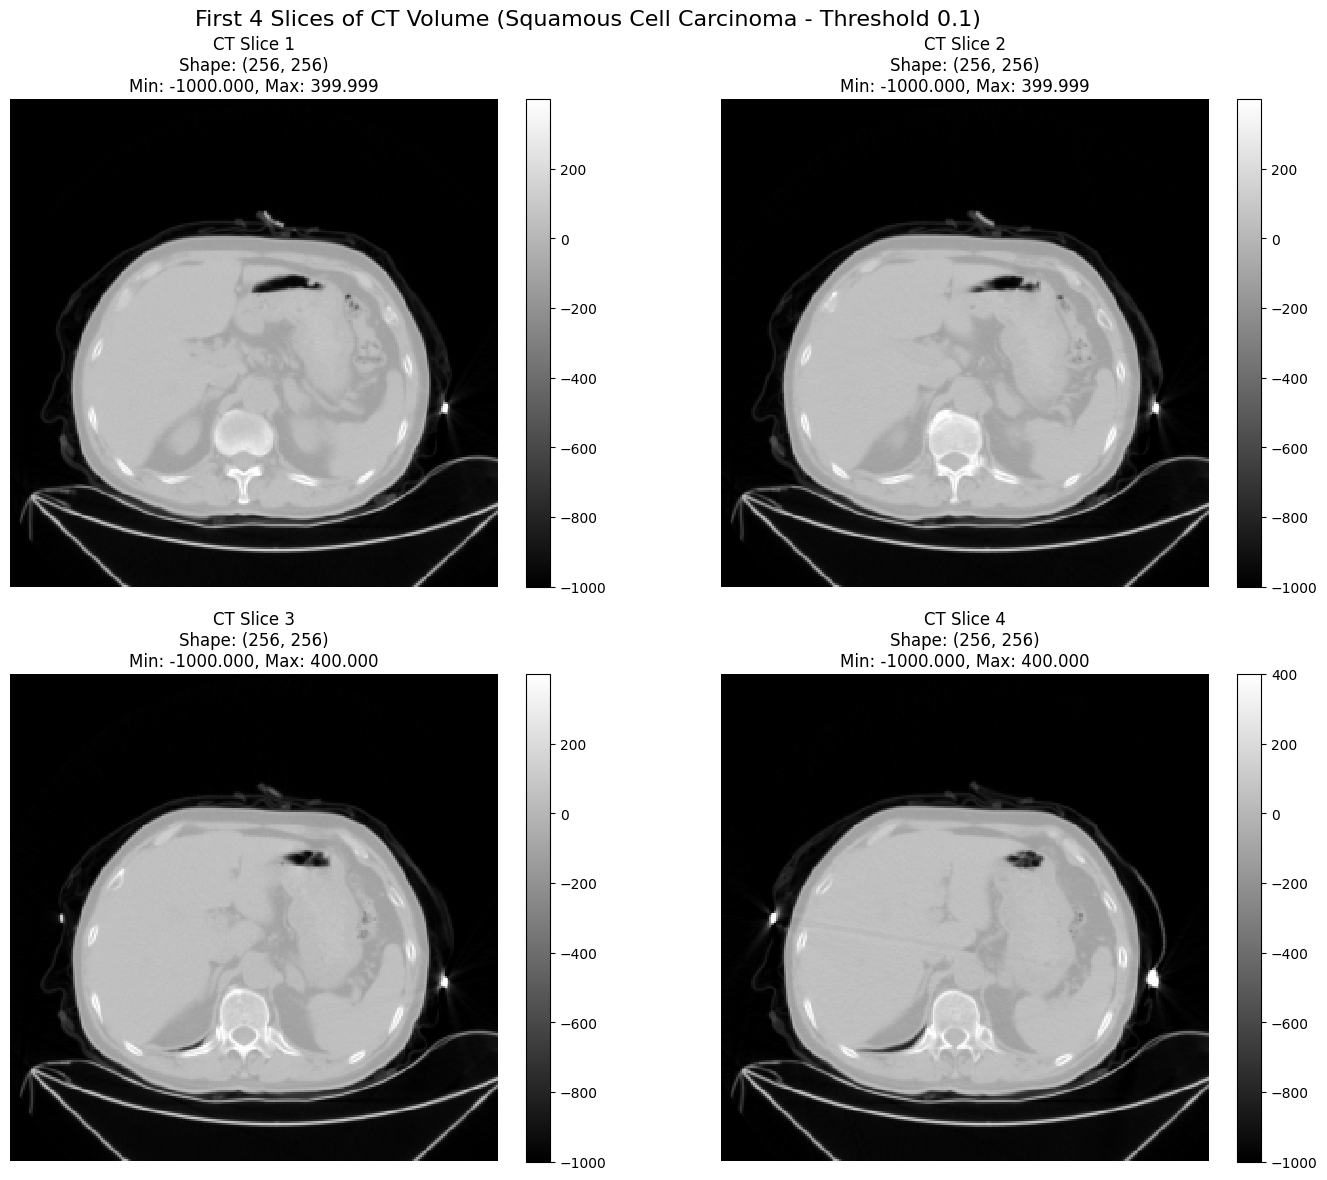

In [4]:
# Visualize the first 4 slices of CT volume
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print(f"Visualizing first 4 slices from {ct_volume.shape[0]} total slices")
print(f"Each slice has shape: {ct_volume.shape[1:]} (height, width)")

for i in range(4):
    if i < ct_volume.shape[0]:
        # Get the i-th slice - shape is [256, 256] (single channel)
        slice_data = ct_volume[i].numpy()  # Shape: [256, 256]
        
        # Display the slice using appropriate colormap for CT (grayscale or bone)
        im = axes[i].imshow(slice_data, cmap='gray', interpolation='nearest')
        axes[i].set_title(f'CT Slice {i+1}\nShape: {slice_data.shape}\nMin: {slice_data.min():.3f}, Max: {slice_data.max():.3f}')
        axes[i].axis('off')
        
        # Add colorbar for each slice
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    else:
        axes[i].set_visible(False)

plt.suptitle('First 4 Slices of CT Volume (Squamous Cell Carcinoma - Threshold 0.1)', fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

In [6]:
sample_slice = np.array(ct_volume[0])

print(len(sample_slice.shape))

2


In [7]:
# samples are in grayscale